In [407]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

from sklearn.datasets import load_iris

In [355]:
x, y = load_iris(return_X_y=True, as_frame=True)

In [356]:
x.shape, y.shape

((150, 4), (150,))

In [357]:
x.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


In [358]:
y.info()

<class 'pandas.Series'>
RangeIndex: 150 entries, 0 to 149
Series name: target
Non-Null Count  Dtype
--------------  -----
150 non-null    int64
dtypes: int64(1)
memory usage: 1.3 KB


In [359]:
y = y.astype('category')

In [360]:
y.describe()

count     150
unique      3
top         0
freq       50
Name: target, dtype: int64

In [361]:
x['target'] = y

In [362]:
x

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


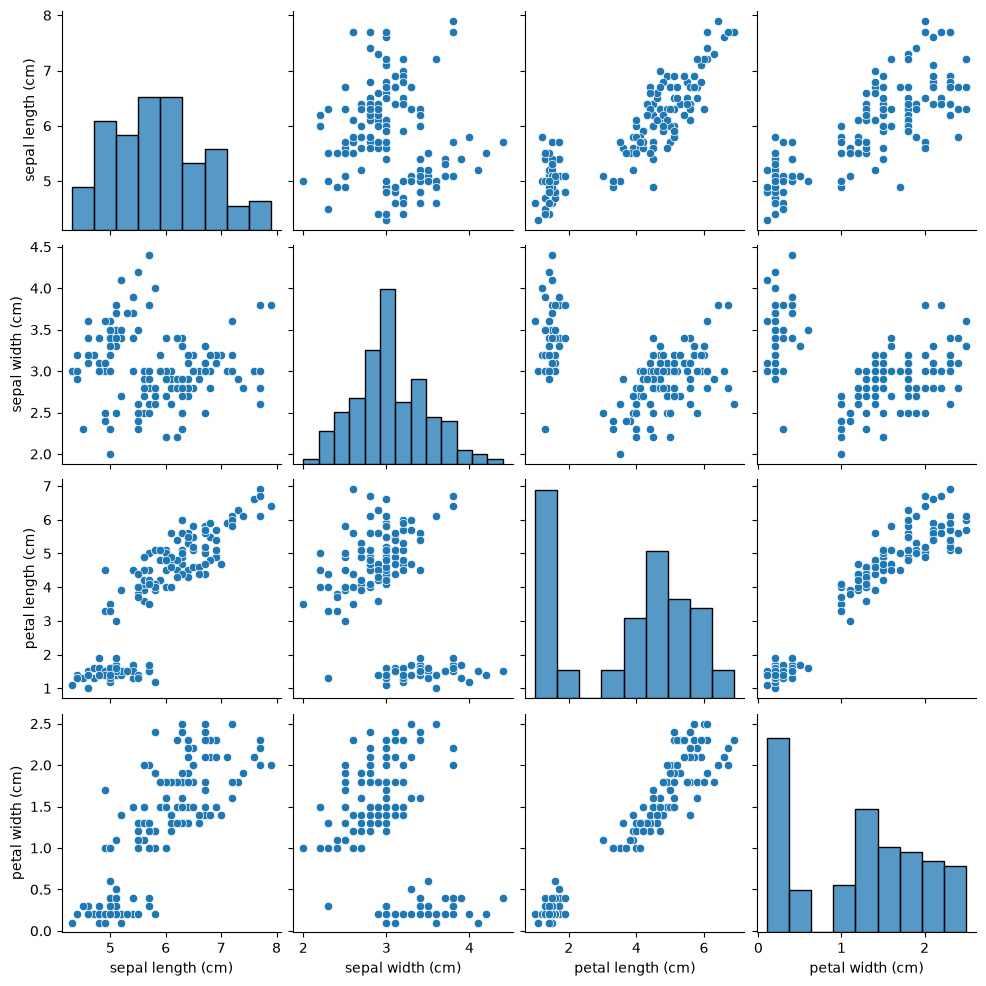

In [363]:
sns.pairplot(x)

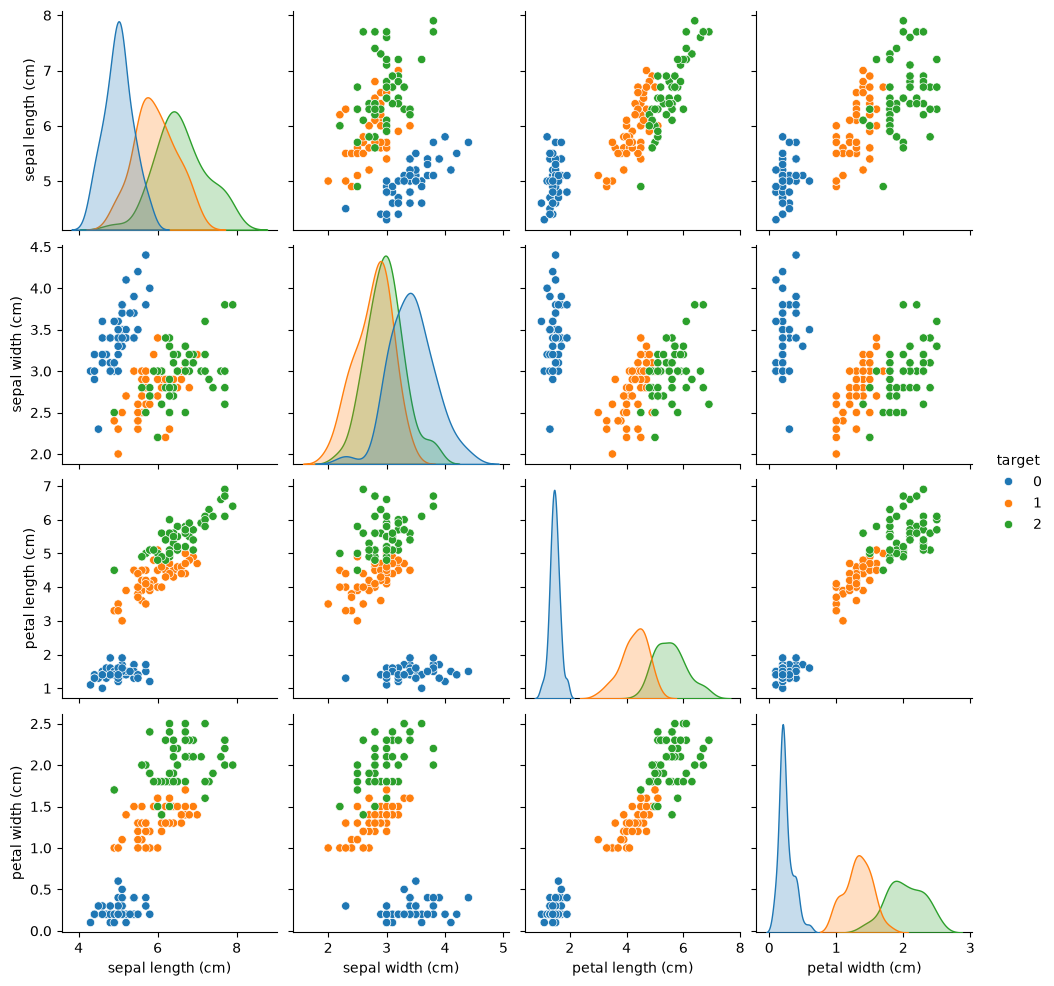

In [364]:
sns.pairplot(x, hue='target')

In [365]:
# x.drop(x[x['target'] == 0].index, inplace= True)
data = x
y = x['target'] #.drop(x[x['target'] == 2].index)
x = x.drop('target', axis=1)

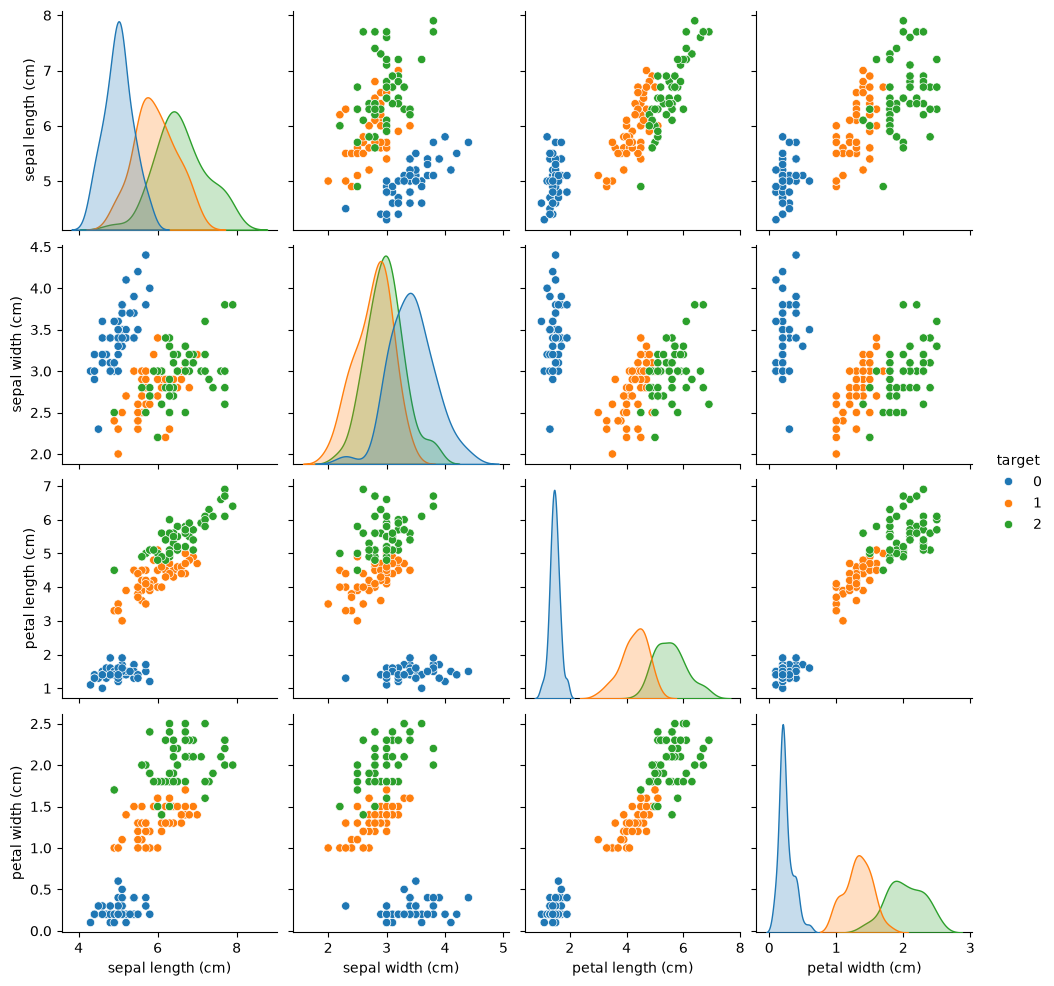

In [366]:
sns.pairplot(data, hue='target')

In [367]:
x.shape

(150, 4)

In [368]:
y.unique()


[0, 1, 2]
Categories (3, int64): [0, 1, 2]

In [392]:
xtrain, xtest, ytrain, ytest =  train_test_split(x, y ,test_size=0.2)

In [393]:
model = LogisticRegression(C=0.5, solver='newton-cg', max_iter=10000)

In [394]:
model.fit(xtrain, ytrain)

,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.5
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'newton-cg'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",10000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penal

In [395]:
model.score(xtrain, ytrain)

0.9666666666666667

In [396]:
model.score(xtest, ytest)

0.9666666666666667

In [398]:
model.classes_

array([0, 1, 2])

In [399]:
model.coef_

array([[-0.38824359,  0.65474757, -1.90529337, -0.81262108],
       [ 0.32250187, -0.35954863, -0.04969968, -0.60610764],
       [ 0.06574172, -0.29519894,  1.95499305,  1.41872872]])

In [400]:
model.intercept_

array([ 7.96945542,  1.85454155, -9.82399697])

In [401]:
model.predict(xtest)

array([1, 1, 2, 1, 2, 2, 0, 0, 2, 0, 2, 2, 1, 2, 0, 1, 1, 1, 1, 1, 2, 1,
       1, 0, 0, 2, 0, 1, 2, 2])

In [409]:
(proba := model.predict_proba(xtest).round(2))

array([[0.  , 0.57, 0.43],
       [0.04, 0.85, 0.1 ],
       [0.  , 0.01, 0.99],
       [0.02, 0.81, 0.17],
       [0.  , 0.06, 0.94],
       [0.  , 0.1 , 0.9 ],
       [0.95, 0.05, 0.  ],
       [0.99, 0.01, 0.  ],
       [0.  , 0.32, 0.68],
       [0.95, 0.05, 0.  ],
       [0.  , 0.27, 0.73],
       [0.  , 0.18, 0.82],
       [0.02, 0.68, 0.3 ],
       [0.  , 0.15, 0.85],
       [0.96, 0.04, 0.  ],
       [0.04, 0.84, 0.12],
       [0.01, 0.78, 0.21],
       [0.05, 0.85, 0.1 ],
       [0.01, 0.68, 0.31],
       [0.04, 0.9 , 0.06],
       [0.  , 0.02, 0.98],
       [0.03, 0.93, 0.04],
       [0.19, 0.8 , 0.01],
       [0.96, 0.04, 0.  ],
       [0.96, 0.04, 0.  ],
       [0.  , 0.43, 0.56],
       [0.96, 0.04, 0.  ],
       [0.12, 0.87, 0.02],
       [0.  , 0.21, 0.79],
       [0.  , 0.09, 0.91]])

In [410]:
preds = []
for p in proba:
    preds.append(np.argmax(p))

preds

[np.int64(1),
 np.int64(1),
 np.int64(2),
 np.int64(1),
 np.int64(2),
 np.int64(2),
 np.int64(0),
 np.int64(0),
 np.int64(2),
 np.int64(0),
 np.int64(2),
 np.int64(2),
 np.int64(1),
 np.int64(2),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(2),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(0),
 np.int64(2),
 np.int64(0),
 np.int64(1),
 np.int64(2),
 np.int64(2)]

In [415]:
print(preds.count(0), preds.count(1), preds.count(2))

7 12 11
